In [112]:
print("hello world")

hello world


In [113]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt


In [114]:
#generatng data for regression task 
# the input is two integers and the output is their sum or product 

def generate_data(n_samples, from_=0, to=10,  operation=['+', '*']):
    X = np.random.randint(from_, to, (n_samples, 2))
    operation = np.random.choice(operation, n_samples)
    #print(operation)
    y = np.zeros(n_samples)
    for i in range(n_samples):
        if operation[i] == '+':
            y[i] = X[i, 0] + X[i, 1]
        else:
            y[i] = X[i, 0] * X[i, 1]
    return X, y, operation

In [115]:
print(generate_data(5, from_=9, to=10))

(array([[9, 9],
       [9, 9],
       [9, 9],
       [9, 9],
       [9, 9]]), array([18., 18., 81., 18., 18.]), array(['+', '+', '*', '+', '+'], dtype='<U1'))


In [116]:
#builing a neural network for regression task
class RegressionNN(nn.Module):
    def __init__(self):
        super(RegressionNN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1) 
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

#the same netwrok but with a third input 
class RegressionNN2(nn.Module):
    def __init__(self):
        super(RegressionNN2, self).__init__()
        self.fc1 = nn.Linear(3, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1) 
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x
# buiding. model with a stochastisity term, to generate outputs stohastically using an embedding that is generated from the input and a random noise
# the embedding is in hte input similar to the vae in the middle of the netwoek we estimate mean and variance of the embedding and we sample from it to generate the output
class StochasticRegressionNN(nn.Module):
    def __init__(self):
        super(StochasticRegressionNN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3_mean = nn.Linear(64, 1)
        self.fc3_logvar = nn.Linear(64, 1)
    def forward(self, x, intervention_z = None):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        mean = self.fc3_mean(x)
        logvar = self.fc3_logvar(x)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mean + eps * std

        return z, mean, logvar

In [117]:
class StochasticNN(nn.Module):
    """
    VAE-style stochastic regressor.
    Encoder: (a, b) -> (mu, log_var) for a latent z of dimension `latent_dim`.
    Decoder: z -> y.

    At training time z is sampled via the reparameterization trick so gradients
    flow through. At generation time calling sample() draws multiple z values
    from the same posterior, producing a spread of outputs that reflects the
    true output distribution (e.g. both 18 and 81 for input (9, 9)).
    """
    def __init__(self, latent_dim: int = 8):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

    def sample(self, x, n_samples: int = 100):
        """Return (n_samples,) predictions for a single input x (shape 1x2)."""
        mu, logvar = self.encode(x)
        mu     = mu.expand(n_samples, -1)
        logvar = logvar.expand(n_samples, -1)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z).squeeze(1)   # (n_samples,)


In [118]:
def train_stochastic(model, X_train, y_train, n_epochs=3000, lr=0.001,
                     batch_size=256, kl_weight=0.01):
    """
    ELBO training: reconstruction MSE + beta * KL(q(z|x) || N(0,I)).

    kl_weight controls the trade-off:
      - too high  -> KL collapses z to N(0,I), model ignores input uncertainty
      - too low   -> z encodes everything deterministically (no diversity)
      - 0.01      -> good starting point for bimodal regression
    """
    device = get_device()
    model.to(device)

    dataset = torch.utils.data.TensorDataset(X_train, y_train)
    loader  = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        model.train()
        total_recon = 0.0
        total_kl    = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            y_hat, mu, logvar = model(xb)
            recon = F.mse_loss(y_hat.squeeze(), yb)
            kl    = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(1).mean()
            loss  = recon + kl_weight * kl
            loss.backward()
            optimizer.step()
            total_recon += recon.item()
            total_kl    += kl.item()
        if (epoch + 1) % 500 == 0:
            n = len(loader)
            print(f'Epoch [{epoch+1}/{n_epochs}]  '
                  f'recon={total_recon/n:.4f}  kl={total_kl/n:.4f}')


In [106]:
model_stoch = StochasticNN(latent_dim=8)

# Re-use X_train / y_train from the cell above (no operator column — model sees only a,b)
train_stochastic(model_stoch, X_train, y_train, n_epochs=3000, kl_weight=0.01)


Epoch [500/3000]  recon=98.0756  kl=28.5461
Epoch [1000/3000]  recon=97.9857  kl=18.4760
Epoch [1500/3000]  recon=99.2134  kl=14.5500
Epoch [2000/3000]  recon=97.8677  kl=13.0125
Epoch [2500/3000]  recon=97.0822  kl=11.3925
Epoch [3000/3000]  recon=97.5390  kl=11.3605


Input: (9, 9)  —  Sampled outputs: mean=47.76  std=0.12
Input: (3, 2)  —  Sampled outputs: mean=5.70  std=0.14
Input: (2, 4)  —  Sampled outputs: mean=7.17  std=0.15


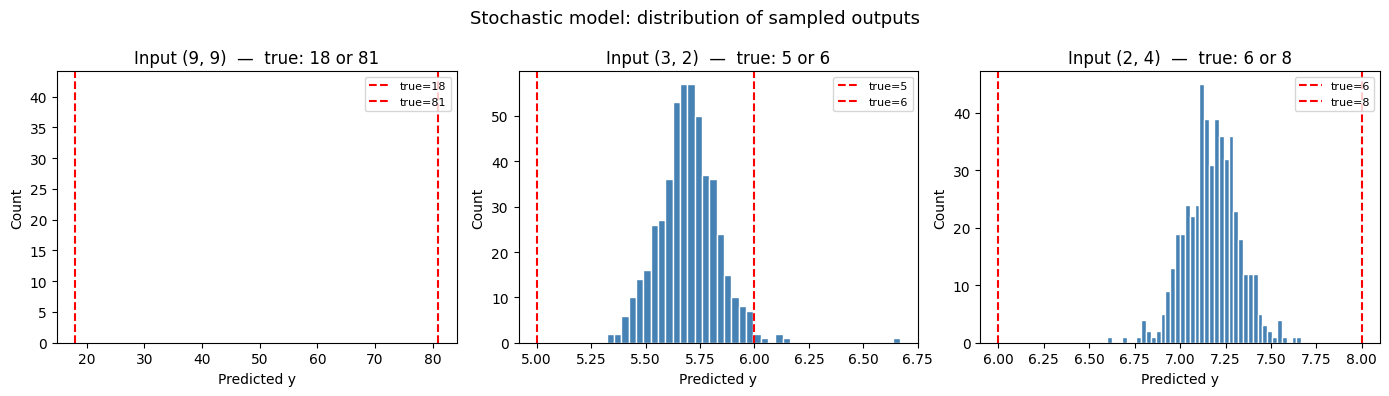

In [107]:
device = get_device()
model_stoch.eval()

test_pairs = [(9, 9), (3, 2), (2, 4)]   # expected: {18,81}, {9,18}, {6,8}

fig, axes = plt.subplots(1, len(test_pairs), figsize=(14, 4))

with torch.no_grad():
    for ax, (a, b) in zip(axes, test_pairs):
        x_in = torch.tensor([[float(a), float(b)]]).to(device)
        samples = model_stoch.sample(x_in, n_samples=500).cpu().numpy()
        print(f'Input: ({a}, {b})  —  Sampled outputs: mean={samples.mean():.2f}  std={samples.std():.2f}')
        ax.hist(samples, bins=40, color='steelblue', edgecolor='white')
        ax.set_title(f'Input ({a}, {b})  —  true: {a+b} or {a*b}')
        ax.set_xlabel('Predicted y')
        ax.set_ylabel('Count')
        for v in [a + b, a * b]:
            ax.axvline(v, color='red', linestyle='--', linewidth=1.5, label=f'true={v}')
        ax.legend(fontsize=8)

plt.suptitle('Stochastic model: distribution of sampled outputs', fontsize=13)
plt.tight_layout()
plt.show()


## Why StochasticNN collapsed to the mean — and the fix

`StochasticNN`'s encoder only sees `(a, b)`. For input `(9, 9)` it receives two training samples that **look identical**:

| x | y |
|---|---|
| (9, 9) | 18  ← addition |
| (9, 9) | 81  ← multiplication |

It has no way to tell them apart, so it maps both to one posterior → decoder compromises → Gaussian around the mean ≈ 49.

**Fix — proper CVAE:** feed `y` to the encoder **during training**.  
Now the encoder sees `(9, 9, 18)` vs `(9, 9, 81)` as different inputs and routes them to different z-regions.  
The decoder learns: *z-region-A → 18, z-region-B → 81*.  
At test time you sample `z ~ N(0, I)` — it can land in either region.


In [108]:
class CVAE(nn.Module):
    """
    Proper Conditional VAE for stochastic regression.

    Training:  encoder sees (a, b, y)  →  q(z | x, y)  — knows which mode
    Test time: sample z ~ N(0, I)      →  decoder(z, x) — hits either mode

    The decoder also receives x so it can use the input as extra context.
    """
    def __init__(self, latent_dim: int = 8):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder q(z|x,y): input is (a, b, y) — 3 values
        self.encoder = nn.Sequential(
            nn.Linear(3, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder p(y|z,x): input is (z, a, b) — latent_dim + 2 values
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + 2, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )

    def encode(self, x, y):
        xy = torch.cat([x, y.unsqueeze(1)], dim=1)   # (B, 3)
        h  = self.encoder(xy)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decoder(torch.cat([z, x], dim=1)), mu, logvar

    def sample(self, x, n_samples: int = 500):
        """Sample from the prior z ~ N(0,I) and decode."""
        x_rep = x.expand(n_samples, -1)
        z     = torch.randn(n_samples, self.latent_dim, device=x.device)
        return self.decoder(torch.cat([z, x_rep], dim=1)).squeeze(1)   # (n_samples,)


In [109]:
def train_cvae(model, X_train, y_train, n_epochs=3000, lr=0.001,
               batch_size=256, kl_weight=0.1):
    device = get_device()
    model.to(device)

    dataset  = torch.utils.data.TensorDataset(X_train, y_train)
    loader   = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        model.train()
        total_recon = 0.0
        total_kl    = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            y_hat, mu, logvar = model(xb, yb)          # encoder sees y during training
            recon = F.mse_loss(y_hat.squeeze(), yb)
            kl    = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(1).mean()
            loss  = recon + kl_weight * kl
            loss.backward()
            optimizer.step()
            total_recon += recon.item()
            total_kl    += kl.item()
        if (epoch + 1) % 500 == 0:
            n = len(loader)
            print(f'Epoch [{epoch+1}/{n_epochs}]  recon={total_recon/n:.4f}  kl={total_kl/n:.4f}')


model_cvae = CVAE(latent_dim=8)
train_cvae(model_cvae, X_train, y_train, n_epochs=3000, kl_weight=0.1)


Epoch [500/3000]  recon=0.0598  kl=3.5305
Epoch [1000/3000]  recon=0.0429  kl=2.6393
Epoch [1500/3000]  recon=0.0341  kl=2.5809
Epoch [2000/3000]  recon=0.0306  kl=2.5478
Epoch [2500/3000]  recon=0.0282  kl=2.4915
Epoch [3000/3000]  recon=0.0347  kl=2.4380


Input: (9, 9)  —  Sampled outputs: mean=30.42  std=14.63
Input: (3, 6)  —  Sampled outputs: mean=14.54  std=9.47
Input: (2, 4)  —  Sampled outputs: mean=9.85  std=8.10


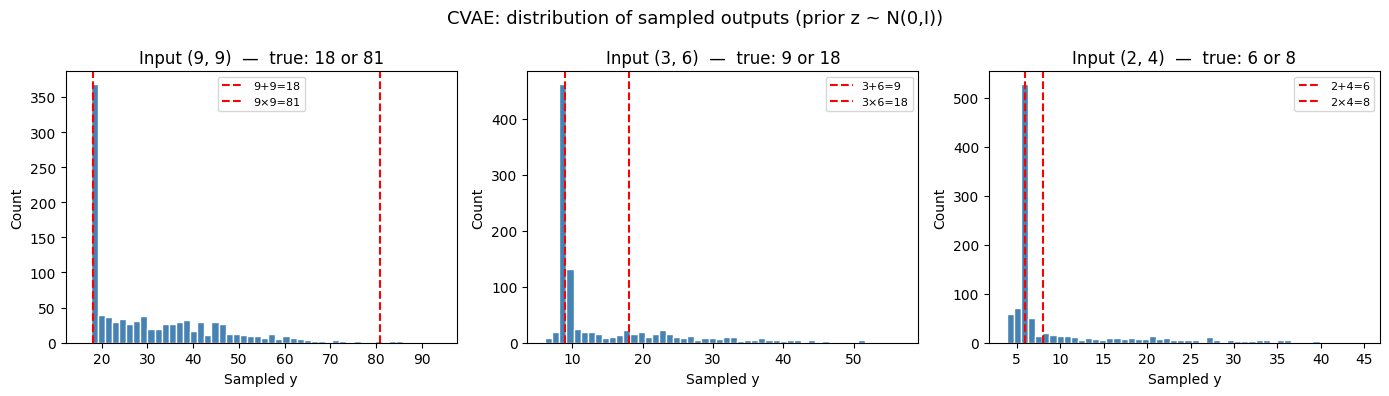

In [111]:
device = get_device()
model_cvae.eval()

test_pairs = [(9, 9), (3, 6), (2, 4)]

fig, axes = plt.subplots(1, len(test_pairs), figsize=(14, 4))

with torch.no_grad():
    for ax, (a, b) in zip(axes, test_pairs):
        x_in  = torch.tensor([[float(a), float(b)]]).to(device)
        samples = model_cvae.sample(x_in, n_samples=1000).cpu().numpy()
        print(f'Input: ({a}, {b})  —  Sampled outputs: mean={samples.mean():.2f}  std={samples.std():.2f}')
        ax.hist(samples, bins=50, color='steelblue', edgecolor='white')
        ax.set_title(f'Input ({a}, {b})  —  true: {a+b} or {a*b}')
        ax.set_xlabel('Sampled y')
        ax.set_ylabel('Count')
        for v, label in [(a + b, f'{a}+{b}={a+b}'), (a * b, f'{a}×{b}={a*b}')]:
            ax.axvline(v, color='red', linestyle='--', linewidth=1.5, label=label)
        ax.legend(fontsize=8)

plt.suptitle('CVAE: distribution of sampled outputs (prior z ~ N(0,I))', fontsize=13)
plt.tight_layout()
plt.show()


In [122]:
class MoGVAE(nn.Module):
    """
    VAE with a Mixture of Gaussians (MoG) decoder.

    Instead of outputting a single value or a single Gaussian,
    the decoder outputs K components: (weights, means, log_vars).
    This can represent ANY distribution — bimodal, skewed, multimodal.

    Loss = -E[log p(y | MoG)]  +  beta * KL(q(z|x) || N(0,I))
           ^^^ this is a KL-based loss, no Gaussian assumption on the output

    For input (9,9): the model can learn weight=0.5 on peak 18, weight=0.5 on peak 81.
    """
    def __init__(self, latent_dim: int = 8, n_components: int = 4):
        super().__init__()
        self.latent_dim = latent_dim
        self.K = n_components

        self.encoder = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
        )
        self.fc_mu_z     = nn.Linear(64, latent_dim)
        self.fc_logvar_z = nn.Linear(64, latent_dim)

        self.dec_hidden   = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU())
        self.dec_weights  = nn.Linear(64, n_components)   # log-weights (before softmax)
        self.dec_means    = nn.Linear(64, n_components)   # component means
        self.dec_logvars  = nn.Linear(64, n_components)   # component log-variances

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu_z(h), self.fc_logvar_z(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def forward(self, x):
        mu_z, logvar_z = self.encode(x)
        z = self.reparameterize(mu_z, logvar_z)
        h = self.dec_hidden(z)
        weights = F.softmax(self.dec_weights(h), dim=-1)   # (B, K)
        means   = self.dec_means(h)                         # (B, K)
        logvars = self.dec_logvars(h)                       # (B, K)
        return weights, means, logvars, mu_z, logvar_z

    def log_prob(self, y, weights, means, logvars):
        """log p(y | MoG) = log sum_k w_k * N(y ; mu_k, sigma_k^2)"""
        y_exp     = y.unsqueeze(1)                                                   # (B, 1)
        log_gauss = -0.5 * (logvars + (y_exp - means).pow(2) / logvars.exp())       # (B, K)
        log_w     = torch.log(weights + 1e-8)                                        # (B, K)
        return torch.logsumexp(log_gauss + log_w, dim=1)                             # (B,)

    def sample(self, x, n_samples: int = 500):
        """Sample y: pick a component via the learned weights, then sample from it."""
        mu_z, logvar_z = self.encode(x)
        mu_z     = mu_z.expand(n_samples, -1)
        logvar_z = logvar_z.expand(n_samples, -1)
        z = self.reparameterize(mu_z, logvar_z)
        h = self.dec_hidden(z)
        weights = F.softmax(self.dec_weights(h), dim=-1)   # (n_samples, K)
        means   = self.dec_means(h)
        logvars = self.dec_logvars(h)

        comp     = torch.multinomial(weights, 1).squeeze(1)                          # (n_samples,)
        idx      = torch.arange(n_samples, device=x.device)
        mu_sel   = means[idx, comp]
        lv_sel   = logvars[idx, comp]
        return mu_sel + torch.randn_like(mu_sel) * torch.exp(0.5 * lv_sel)          # (n_samples,)


def train_mog_vae(model, X_train, y_train, n_epochs=3000, lr=0.001,
                  batch_size=256, kl_weight=0.01):
    device = get_device()
    model.to(device)
    dataset  = torch.utils.data.TensorDataset(X_train, y_train)
    loader   = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        model.train()
        total_nll, total_kl = 0.0, 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            weights, means, logvars, mu_z, logvar_z = model(xb)
            nll  = -model.log_prob(yb, weights, means, logvars).mean()
            kl   = -0.5 * (1 + logvar_z - mu_z.pow(2) - logvar_z.exp()).sum(1).mean()
            loss = nll + kl_weight * kl
            loss.backward()
            optimizer.step()
            total_nll += nll.item()
            total_kl  += kl.item()
        if (epoch + 1) % 500 == 0:
            n = len(loader)
            print(f'Epoch [{epoch+1}/{n_epochs}]  nll={total_nll/n:.4f}  kl={total_kl/n:.4f}')


model_mog = MoGVAE(latent_dim=8, n_components=4)
train_mog_vae(model_mog, X_train, y_train, n_epochs=500, kl_weight=0.01)


Epoch [500/500]  nll=-1.4262  kl=43.1737


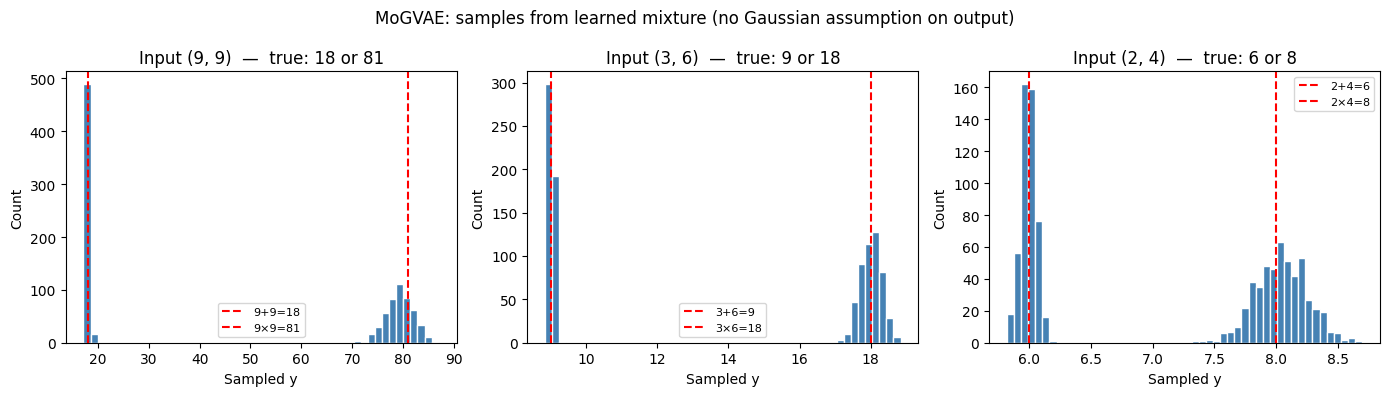

In [123]:
device = get_device()
model_mog.eval()

test_pairs = [(9, 9), (3, 6), (2, 4)]

fig, axes = plt.subplots(1, len(test_pairs), figsize=(14, 4))

with torch.no_grad():
    for ax, (a, b) in zip(axes, test_pairs):
        x_in    = torch.tensor([[float(a), float(b)]]).to(device)
        samples = model_mog.sample(x_in, n_samples=1000).cpu().numpy()

        ax.hist(samples, bins=50, color='steelblue', edgecolor='white')
        ax.set_title(f'Input ({a}, {b})  —  true: {a+b} or {a*b}')
        ax.set_xlabel('Sampled y')
        ax.set_ylabel('Count')
        for v, label in [(a+b, f'{a}+{b}={a+b}'), (a*b, f'{a}×{b}={a*b}')]:
            ax.axvline(v, color='red', linestyle='--', linewidth=1.5, label=label)
        ax.legend(fontsize=8)

plt.suptitle('MoGVAE: samples from learned mixture (no Gaussian assumption on output)', fontsize=12)
plt.tight_layout()
plt.show()


In [127]:
class VAERegressor(nn.Module):
    """
    Standard VAE where the decoder does the regression task instead of image reconstruction.

    Encoder : (a, b) -> (mu_z, log_var_z)  in R^2   (2D so we can plot it)
    Sample  : z = mu_z + eps * sigma_z               (reparameterization)
    Decoder : z -> predicted y                        (the actual task)

    Loss = MSE(y_hat, y_true)  +  beta * KL(q(z|x) || N(0,I))
           ^^^ task loss              ^^^ forces latent space to be smooth

    Why this works even though MSE alone collapses to the mean:
    The KL term forces the encoder to spread different inputs across the latent
    space in a structured way. The decoder then has to map each region of that
    2D space to a meaningful prediction, which creates a smooth manifold instead
    of a single average point.
    """
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(64, 2)   # 2D latent space
        self.fc_logvar = nn.Linear(64, 2)

        self.decoder = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


def train_vae_regressor(model, X_train, y_train, n_epochs=3000, lr=0.001,
                        batch_size=256, kl_weight=0.1):
    device = get_device()
    model.to(device)
    dataset  = torch.utils.data.TensorDataset(X_train, y_train)
    loader   = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        model.train()
        total_mse, total_kl = 0.0, 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            y_hat, mu, logvar = model(xb)
            mse  = F.mse_loss(y_hat.squeeze(), yb)
            kl   = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(1).mean()
            loss = mse + kl_weight * kl
            loss.backward()
            optimizer.step()
            total_mse += mse.item()
            total_kl  += kl.item()
        if (epoch + 1) % 500 == 0:
            n = len(loader)
            print(f'Epoch [{epoch+1}/{n_epochs}]  mse={total_mse/n:.4f}  kl={total_kl/n:.4f}')


model_vae = VAERegressor()
train_vae_regressor(model_vae, X_train, y_train, n_epochs=500, kl_weight=0.1)


Epoch [500/500]  mse=98.4417  kl=4.5490


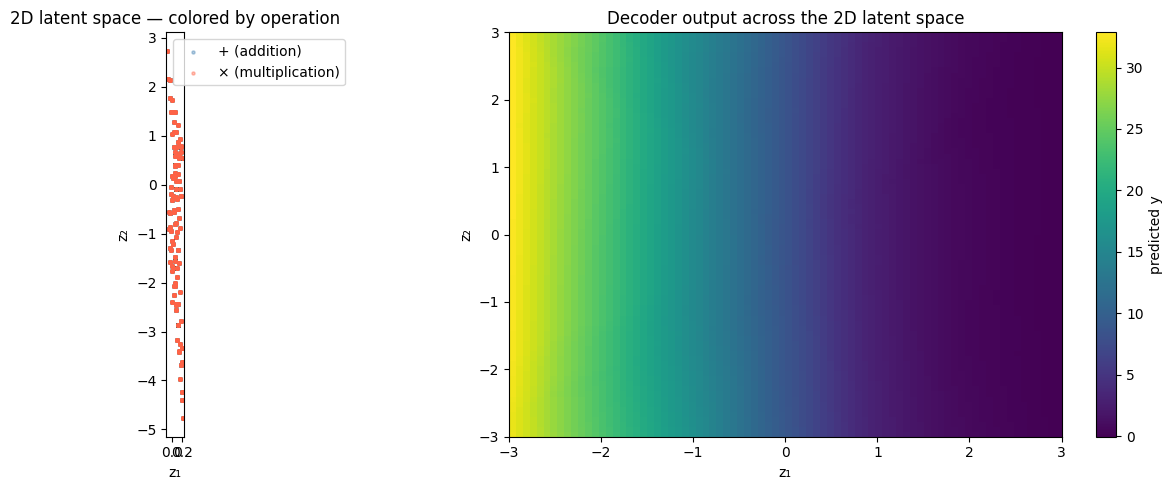

In [128]:
device = get_device()
model_vae.eval()

# --- encode all training points to get their 2D latent coordinates ---
with torch.no_grad():
    mu_all, _ = model_vae.encode(X_train.to(device))
    mu_all    = mu_all.cpu().numpy()                  # (N, 2)

op_labels = operation_train.numpy()                   # 0=plus, 1=times

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: latent space colored by operation ---
ax = axes[0]
sc = ax.scatter(mu_all[op_labels==0, 0], mu_all[op_labels==0, 1],
                s=5, alpha=0.4, label='+ (addition)',       color='steelblue')
sc = ax.scatter(mu_all[op_labels==1, 0], mu_all[op_labels==1, 1],
                s=5, alpha=0.4, label='× (multiplication)', color='tomato')
ax.set_title('2D latent space — colored by operation')
ax.set_xlabel('z₁')
ax.set_ylabel('z₂')
ax.legend()
ax.set_aspect('equal')

# --- Plot 2: decoder output heatmap over the 2D latent grid ---
ax = axes[1]
res  = 80
lim  = 3.0
grid = torch.linspace(-lim, lim, res)
zz1, zz2 = torch.meshgrid(grid, grid, indexing='ij')
z_grid = torch.stack([zz1.flatten(), zz2.flatten()], dim=1).to(device)

with torch.no_grad():
    preds = model_vae.decoder(z_grid).squeeze().cpu().numpy().reshape(res, res)

im = ax.imshow(preds, origin='lower', extent=[-lim, lim, -lim, lim],
               cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label='predicted y')
ax.set_title('Decoder output across the 2D latent space')
ax.set_xlabel('z₁')
ax.set_ylabel('z₂')

plt.tight_layout()
plt.show()


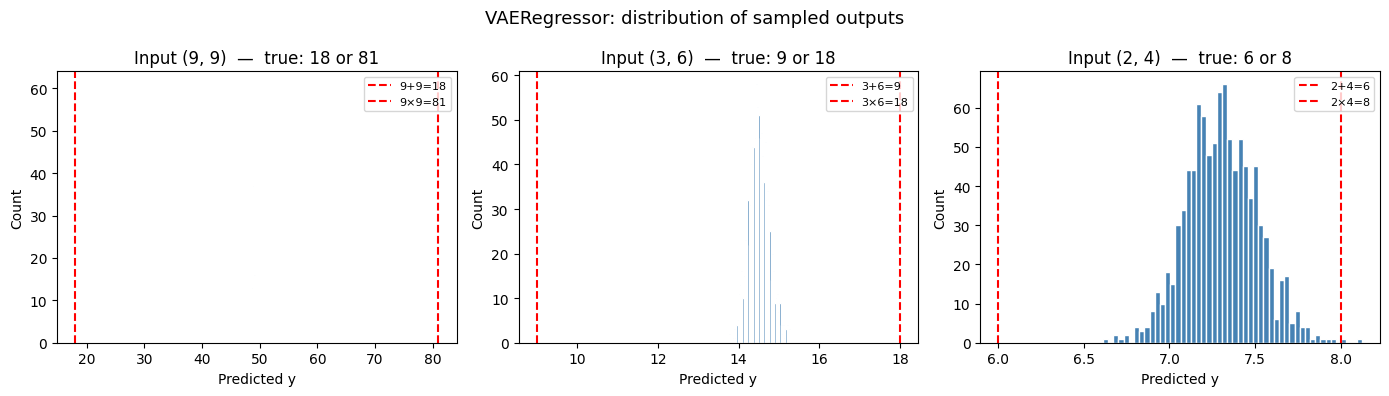

In [130]:
device = get_device()
model_vae.eval()

test_pairs = [(9, 9), (3, 6), (2, 4)]

fig, axes = plt.subplots(1, len(test_pairs), figsize=(14, 4))

with torch.no_grad():
    for ax, (a, b) in zip(axes, test_pairs):
        x_in = torch.tensor([[float(a), float(b)]]).to(device)

        # sample z ~ q(z|x) n_samples times, decode each one
        mu, logvar = model_vae.encode(x_in)
        mu     = mu.expand(1000, -1)
        logvar = logvar.expand(1000, -1)
        z      = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        samples = model_vae.decoder(z).squeeze().cpu().numpy()

        ax.hist(samples, bins=50, color='steelblue', edgecolor='white')
        ax.set_title(f'Input ({a}, {b})  —  true: {a+b} or {a*b}')
        ax.set_xlabel('Predicted y')
        ax.set_ylabel('Count')
        for v, label in [(a+b, f'{a}+{b}={a+b}'), (a*b, f'{a}×{b}={a*b}')]:
            ax.axvline(v, color='red', linestyle='--', linewidth=1.5, label=label)
        ax.legend(fontsize=8)

plt.suptitle('VAERegressor: distribution of sampled outputs', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
#plotting the distribution of sampled outputs for some test inputs



AttributeError: 'VAERegressor' object has no attribute 'sample'

In [125]:
#coputing hte mse of the model
def compute_mse(model, X_test, y_test):
    device = get_device()
    model.to(device)
    model.eval()
    with torch.no_grad():
        X_test, y_test = X_test.to(device), y_test.to(device)
        weights, means, logvars, _, _ = model(X_test)
        # For MSE, we can use the mean of the mixture as the prediction
        pred = (weights * means).sum(dim=1)  # (N,)
        mse = F.mse_loss(pred, y_test)
    return mse.item()

mse_mog = compute_mse(model_mog, X_test, y_test)
print(f'MoGVAE MSE on test set: {mse_mog:.4f}')

MoGVAE MSE on test set: 102.7848


In [82]:
def get_device():
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

def train(model, X_train, y_train, n_epochs=1000, learning_rate=0.001, batch_size=256):
    device = get_device()
    model.to(device)

    dataset = torch.utils.data.TensorDataset(X_train, y_train)
    loader  = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            if isinstance(out, tuple):
                out = out[0]   # StochasticRegressionNN returns (z, mean, logvar)
            loss = criterion(out.squeeze(), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {total_loss / len(loader):.4f}')


In [83]:
device = get_device()
print(f"Training on: {device}")

X_train, y_train, operation_train = generate_data(10000, from_=0, to=10, operation=['+', '*'])
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
operation = [0 if op == '+' else 1 for op in operation_train]
operation_train = torch.tensor(operation, dtype=torch.float32)

model1 = RegressionNN()
model2 = RegressionNN2()

print("--- Training model1 (no operator) ---")
train(model1, X_train, y_train, n_epochs=2000, learning_rate=0.001)

X_train_with_op = torch.cat((X_train, operation_train.unsqueeze(1)), dim=1)
print("\n--- Training model2 (with operator) ---")
train(model2, X_train_with_op, y_train, n_epochs=2000, learning_rate=0.001)


Training on: mps
--- Training model1 (no operator) ---
Epoch [100/2000], Loss: 98.6700
Epoch [200/2000], Loss: 97.3411
Epoch [300/2000], Loss: 98.4598
Epoch [400/2000], Loss: 98.4262
Epoch [500/2000], Loss: 97.9702
Epoch [600/2000], Loss: 99.2414
Epoch [700/2000], Loss: 99.0851
Epoch [800/2000], Loss: 99.4542
Epoch [900/2000], Loss: 99.4871
Epoch [1000/2000], Loss: 97.6117
Epoch [1100/2000], Loss: 100.4142
Epoch [1200/2000], Loss: 98.9816
Epoch [1300/2000], Loss: 97.9559
Epoch [1400/2000], Loss: 97.7164
Epoch [1500/2000], Loss: 97.6648
Epoch [1600/2000], Loss: 97.4240
Epoch [1700/2000], Loss: 97.5548
Epoch [1800/2000], Loss: 97.0267
Epoch [1900/2000], Loss: 98.6989
Epoch [2000/2000], Loss: 98.1335

--- Training model2 (with operator) ---
Epoch [100/2000], Loss: 0.0374
Epoch [200/2000], Loss: 0.0190
Epoch [300/2000], Loss: 0.0250
Epoch [400/2000], Loss: 0.0431
Epoch [500/2000], Loss: 0.0282
Epoch [600/2000], Loss: 0.0044
Epoch [700/2000], Loss: 0.0055
Epoch [800/2000], Loss: 0.0248
Epoc

In [88]:
device = get_device()
X_test, y_test, _ = generate_data(1000, from_=0, to=10, operation=['+', '*'])
X_test  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test  = torch.tensor(y_test,  dtype=torch.float32).to(device)

model1.eval()
with torch.no_grad():
    predictions = model1(X_test).squeeze()
mse = nn.MSELoss()(predictions, y_test)
print(f'Model1 Test MSE: {mse.item():.4f}')
#priting some predictions vs true values for model1
print("\nModel1 Predictions vs True Values:")
for i in range(10):
    print(f"Input: {X_test[i].cpu().numpy()}, Prediction: {predictions[i].item():.4f}, True Value: {y_test[i].item():.4f}")


Model1 Test MSE: 103.4001

Model1 Predictions vs True Values:
Input: [5. 0.], Prediction: 3.0572, True Value: 5.0000
Input: [5. 4.], Prediction: 15.0138, True Value: 20.0000
Input: [0. 0.], Prediction: 0.1231, True Value: 0.0000
Input: [6. 3.], Prediction: 14.4246, True Value: 18.0000
Input: [7. 3.], Prediction: 16.2757, True Value: 10.0000
Input: [0. 3.], Prediction: 1.6202, True Value: 0.0000
Input: [9. 7.], Prediction: 39.1607, True Value: 63.0000
Input: [9. 2.], Prediction: 14.6799, True Value: 11.0000
Input: [9. 9.], Prediction: 49.1902, True Value: 81.0000
Input: [9. 3.], Prediction: 20.2418, True Value: 12.0000


In [85]:
device = get_device()
X_test, y_test, operation_test = generate_data(1000, from_=0, to=10, operation=['+', '*'])
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)
op_test = torch.tensor([0 if op == '+' else 1 for op in operation_test], dtype=torch.float32)
X_test_with_op = torch.cat((X_test, op_test.unsqueeze(1)), dim=1).to(device)
y_test = y_test.to(device)

model2.eval()
with torch.no_grad():
    predictions = model2(X_test_with_op).squeeze()
mse = nn.MSELoss()(predictions, y_test)
print(f'Model2 Test MSE: {mse.item():.4f}')

print("\nSample predictions:")
for i in range(10):
    print(f'  Input: {X_test[i].tolist()}, op={"+" if op_test[i]==0 else "*"}, '
          f'Pred: {predictions[i].item():.2f}, True: {y_test[i].item():.2f}')


Model2 Test MSE: 0.0011

Sample predictions:
  Input: [1.0, 1.0], op=+, Pred: 1.99, True: 2.00
  Input: [2.0, 8.0], op=+, Pred: 9.98, True: 10.00
  Input: [5.0, 0.0], op=*, Pred: -0.01, True: 0.00
  Input: [6.0, 1.0], op=+, Pred: 6.97, True: 7.00
  Input: [7.0, 1.0], op=*, Pred: 6.99, True: 7.00
  Input: [6.0, 7.0], op=+, Pred: 12.98, True: 13.00
  Input: [3.0, 3.0], op=*, Pred: 8.99, True: 9.00
  Input: [2.0, 0.0], op=*, Pred: 0.00, True: 0.00
  Input: [0.0, 4.0], op=+, Pred: 4.01, True: 4.00
  Input: [5.0, 9.0], op=*, Pred: 45.02, True: 45.00


In [86]:
#printing examples of predictions
for i in range(10):
    print(f'Input: {X_test[i].numpy()}, Prediction: {predictions[i].item()}, True Value: {y_test[i].item()}')  
    

Input: [1. 1.], Prediction: 1.9867528676986694, True Value: 2.0
Input: [2. 8.], Prediction: 9.975156784057617, True Value: 10.0
Input: [5. 0.], Prediction: -0.00747690349817276, True Value: 0.0
Input: [6. 1.], Prediction: 6.974134922027588, True Value: 7.0
Input: [7. 1.], Prediction: 6.986073017120361, True Value: 7.0
Input: [6. 7.], Prediction: 12.982495307922363, True Value: 13.0
Input: [3. 3.], Prediction: 8.98592758178711, True Value: 9.0
Input: [2. 0.], Prediction: 0.0013636574149131775, True Value: 0.0
Input: [0. 4.], Prediction: 4.010560035705566, True Value: 4.0
Input: [5. 9.], Prediction: 45.02054977416992, True Value: 45.0


In [50]:
# trying the model 
model.eval()
with torch.no_grad():
    X_test, y_test = generate_data(10, from_=9, to=10, operation=['+', '*'])
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)
    predictions = model(X_test)
    mean = predictions[1]
    logvar = predictions[2]
    predictions = predictions[0].squeeze()

    for i in range(len(X_test)):
        print(f'Input: {X_test[i].tolist()}, Predicted: {predictions[i].item():.4f}, Actual: {y_test[i].item():.4f}')
        #print(f'Mean: {mean[i].item():.4f}, LogVar: {logvar[i].item():.4f}')

Input: [9.0, 9.0], Predicted: 44.8197, Actual: 18.0000
Input: [9.0, 9.0], Predicted: 44.8197, Actual: 81.0000
Input: [9.0, 9.0], Predicted: 44.8197, Actual: 18.0000
Input: [9.0, 9.0], Predicted: 44.8197, Actual: 81.0000
Input: [9.0, 9.0], Predicted: 44.8197, Actual: 18.0000
Input: [9.0, 9.0], Predicted: 44.8197, Actual: 81.0000
Input: [9.0, 9.0], Predicted: 44.8197, Actual: 18.0000
Input: [9.0, 9.0], Predicted: 44.8197, Actual: 18.0000
Input: [9.0, 9.0], Predicted: 44.8197, Actual: 18.0000
Input: [9.0, 9.0], Predicted: 44.8197, Actual: 81.0000
